In [1]:
# !pip install dtreeviz

In [21]:
import numpy as np

In [2]:
import graphviz.backend as be

In [3]:
from sklearn.datasets import load_iris
from dtreeviz import model
from IPython.display import Image, display_svg, SVG
from sklearn import tree

In [4]:
clas = tree.DecisionTreeClassifier(max_depth=2)  
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]')]

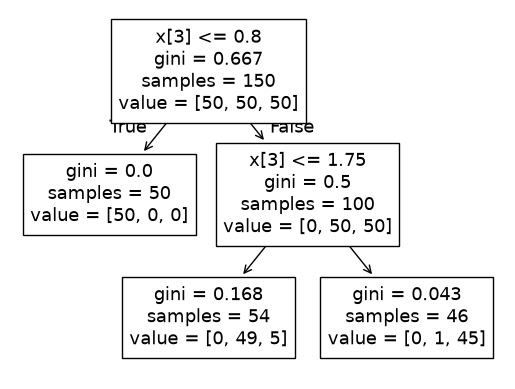

In [5]:
from sklearn.tree import plot_tree
plot_tree(clas)

# 1. Classification

In [6]:
viz =model(clas, 
               X_train,
               y_train,
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"]
          )           
viz

In [7]:
#viz.view()

# 2. Regression

In [14]:
from sklearn.datasets import fetch_california_housing
regr = tree.DecisionTreeRegressor(max_depth=1)
boston =fetch_california_housing()

X_train = boston.data
y_train = boston.target
regr.fit(X_train, y_train)

viz = model(regr,
               X_train,
               y_train,
               target_name='price',
               feature_names=boston.feature_names
              )
viz

# 3. Horizontal Decision Tree

In [19]:
viz = model(clas, 
               X_train,
               y_train,
               target_name='price',
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"],
           )
viz

# 4. Show prediction path

In [25]:
clas = tree.DecisionTreeClassifier()  
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)),:]

viz =model(clas, 
               X_train,
               y_train,
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"]
          )
viz

# 5. Show node number

In [29]:
viz =model(clas, 
               X_train,
               y_train,
               target_name='price',
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"]
          )
viz

# 6. Without Any graphs

In [33]:
viz = model(clas, 
               X_train,
               y_train,
               target_name='price',
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"]
            )
viz

# 7. Show just prediction path, nothing else

In [34]:
clas = tree.DecisionTreeClassifier()  
iris = load_iris()

X_train = iris.data
y_train = iris.target
clas.fit(X_train, y_train)

X = iris.data[np.random.randint(0, len(iris.data)),:]

viz = model(clas, 
               X_train,
               y_train,
               target_name='price',
               feature_names=iris.feature_names, 
               class_names=["setosa", "versicolor", "virginica"])
viz

# 8. Prediction Path in Plain english

In [46]:

#print(explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type="plain_english"))
     

# 9. Feature Importance

In [48]:
#print(explain_prediction_path(clas, X, feature_names=iris.feature_names, explanation_type="sklearn_default"))

# 10. Univariate Regression

In [54]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.tree import DecisionTreeRegressor
# from dtreeviz.trees import *

# df_cars = pd.read_csv("cars.csv")
# X, y = df_cars[['WGT']], df_cars['MPG']

# dt = DecisionTreeRegressor(max_depth=3, criterion="mae")
# dt.fit(X, y)

# fig = plt.figure()
# ax = fig.gca()
# rtreeviz_univar(dt, X, y, 'WGT', 'MPG', ax=ax)
# plt.show()

# 11. 3-D Regression


In [55]:
#df_cars = pd.read_csv("cars.csv")

# df_cars

In [52]:
# from mpl_toolkits.mplot3d import Axes3D
# from sklearn.tree import DecisionTreeRegressor
# from dtreeviz.trees import *


# X = df_cars[['WGT','ENG']]
# y = df_cars['MPG']

# dt = DecisionTreeRegressor(max_depth=3, criterion="mae")
# dt.fit(X, y)

# figsize = (6,5)
# fig = plt.figure(figsize=figsize)
# ax = fig.add_subplot(111, projection='3d')

# t = rtreeviz_bivar_3D(dt,
#                       X, y,
#                       feature_names=['Vehicle Weight', 'Horse Power'],
#                       target_name='MPG',
#                       fontsize=14,
#                       elev=20,
#                       azim=25,
#                       dist=8.2,
#                       show={'splits','title'},
#                       ax=ax)
# plt.show()